# Materials ML - Homework: Linear & Polynomial Regression

Welcome! 👋 In this homework you'll practise fitting regression models to **real-looking materials data** using Python - and, just as importantly, you'll think critically about *when a linear model is actually the right tool*.

There are two parts:

| Part | Materials problem | Model |
|------|-------------------|-------|
| **A** | Young's modulus from a tensile test | straight-line linear regression |
| **B** | Thermal expansion of a metal | polynomial regression |

**How to use this notebook**
- Cells marked **✏️ TODO** are for you to complete - fill in the missing lines.
- Cells marked **🤔 Reflection** ask you to *write a short answer* in the markdown cell (double-click to edit).
- Some cells are already complete - read them, run them, and make sure you understand what they do.

> As usual, you can upload this notebook to your jupyter folder, and 📁 Keep `tensile_test.csv` and `thermal_expansion.csv` in the **same folder** as this notebook, so the `read_csv` lines below can find them.

Let's go!

In [ ]:
# Setup - run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats  #if this raises an error, try installing scipy in your anaconda prompt (conda install scipy)

---
## Part A - Young's Modulus from a Tensile Test

When you pull on a metal specimen, it stretches. In the **elastic region**, stress and strain follow *Hooke's law*, a straight line:

$$ \sigma = E \, \varepsilon $$

where $\sigma$ is stress, $\varepsilon$ is strain, and the slope $E$ is the material's **Young's modulus** - a genuine, look-it-up property.

Your dataset `tensile_test.csv` has two columns:
- `strain` - how much the specimen stretched (dimensionless)
- `stress_mpa` - the stress applied, in megapascals (MPa)

**Your mission:** fit a line to recover $E$ - *and* figure out where the straight-line model stops being valid.

In [26]:
# ✏️ TODO: Load the data (check file name)
tensile = pd.read_csv("data/week03-HW_tensile_test.csv")
tensile.head()

,strain,stress_mpa
0,0.00000,0.0
1,0.00012,24.9
2,0.00024,47.5
3,0.00035,70.1
4,0.00047,95.3


### Task A1 - Look before you fit

Always eyeball the data first. Run the scatter plot below. **Does it look like a single straight line all the way across?** Keep your answer in mind for later.

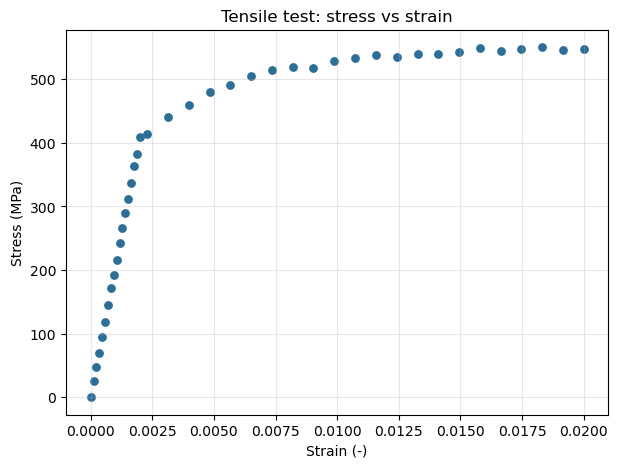

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(tensile["strain"], tensile["stress_mpa"], s=28, color="#2a6f97")
plt.xlabel("Strain (-)")
plt.ylabel("Stress (MPa)")
plt.title("Tensile test: stress vs strain")
plt.grid(alpha=0.3)
plt.show()

### ✏️ Task A2 - Fit a straight line to **all** the data

Use scikit-learn's `LinearRegression`. Note that sklearn wants `X` as a **2-D** array - the double brackets `[["strain"]]` take care of that.

Complete the three TODO lines.

In [36]:
X = tensile[["strain"]].values      # 2-D feature array
y = tensile["stress_mpa"].values    # target

model_full = LinearRegression()

# ✏️ TODO 1: fit the model to X and y
result_full = model_full.fit(X,y)


In [37]:
# ✏️ TODO 2: read off the slope and intercept
slope_full     = model_full.coef_[0]
intercept_full = model_full.intercept_

In [38]:
# ✏️ TODO 3: compute R^2 using model_full.predict(X) and r2_score(...)
y_pred = model_full.predict(X)
r2_full = r2_score(y,y_pred)

In [39]:
print(f"slope = {slope_full:,.0f} MPa   intercept = {intercept_full:.1f} MPa   R^2 = {r2_full:.3f}")

slope = 22,127 MPa   intercept = 231.0 MPa   R^2 = 0.633


### ✏️ Task A3 - Draw the fit, then look at the residuals

A **residual** is the vertical gap between a data point and the fitted line ($\text{residual} = y - \hat{y}$). If a straight line is a good model, the residuals should look like random noise scattered around zero - *no pattern*.

Complete the TODO to draw the fitted line. The residual plot below it is already written for you.

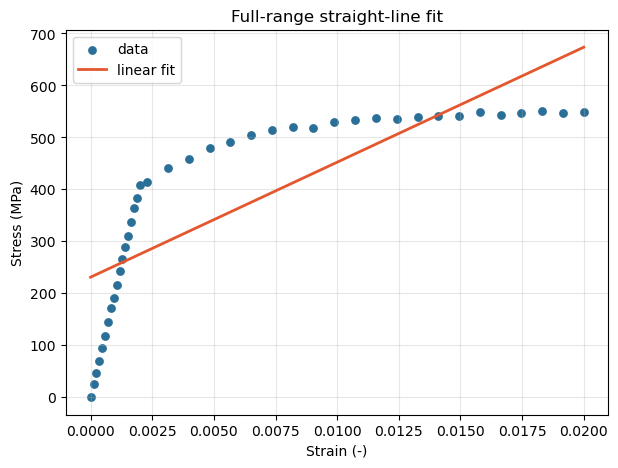

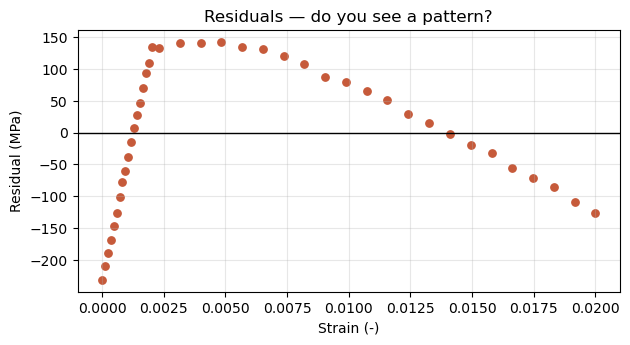

In [43]:
# Fitted line over the data (generating the x-data for the full region)
x_line = np.linspace(tensile["strain"].min(), tensile["strain"].max(), 100).reshape(-1, 1)

# plotting the original data
plt.figure(figsize=(7, 5))
plt.scatter(tensile["strain"], tensile["stress_mpa"], s=28, color="#2a6f97", label="data")

# ✏️ TODO: plot the linear regression model for the full dataset (use the x_line as the X data)
y_predict = model_full.predict(x_line)
plt.plot(x_line,y_predict, color="#e4572e", lw=2, label="linear fit")

plt.xlabel("Strain (-)"); plt.ylabel("Stress (MPa)")
plt.legend(); plt.grid(alpha=0.3); plt.title("Full-range straight-line fit")
plt.show()

# Residual plot (already complete - just run it)
residuals = y - model_full.predict(X)
plt.figure(figsize=(7, 3.4))
plt.scatter(tensile["strain"], residuals, s=28, color="#c65a3a")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Strain (-)"); plt.ylabel("Residual (MPa)")
plt.title("Residuals — do you see a pattern?")
plt.grid(alpha=0.3)
plt.show()


### 🤔 Reflection A (double-click to write your answers)

1. The straight line through all the points - how well does it match the data by eye?
2. Look at the residual plot. Is it patternless noise, or is there a clear shape? What does that tell you about whether a *single* straight line is the right model here?
3. In physical terms, what is happening to the specimen in the region where the line stops fitting well? *(Hint: what happens to metal when you stretch it too far?)*

**Your answers:**

1. The straight line does not fit the data - it doesn't fit the elastic region, or the overal data. Although the R2 value (0.63)  suggests there is some level of fitting - visual inspection shows that it is very poor! 
2. There's a distinct pattern in the residual plot. Even after fitting a regression line, the remaining data shows a clear pattern - indicating that linear regression is 'underfitting' the data.
3. It loses its' ability to return to its original shape - as it has exceeded its elastic limit

### ✏️ Task A4 - Fit only the region where the model is valid

Hooke's law only holds in the **elastic region** - the initial straight part of the curve. Pick a strain cut-off that keeps just that part, then refit.

In [17]:
# ✏️ TODO: choose a strain cut-off for the straight (elastic) region.
# Look back at your scatter plot - where does it stop being straight?
elastic_cutoff = 0.002      # e.g. somewhere near 0.002

mask  = tensile["strain"] <= elastic_cutoff
X_el  = tensile.loc[mask, ["strain"]].values
y_el  = tensile.loc[mask, "stress_mpa"].values

model_el = LinearRegression()
# ✏️ TODO: fit model_el on the elastic data, then compute its R^2
result_el = model_el.fit(X_el,y_el)
r2_el = r2_score(y_el, model_el.predict(X_el))
print(f"elastic slope = {model_el.coef_[0]:,.0f} MPa   R^2 = {r2_el:.4f}")

elastic slope = 205,115 MPa   R^2 = 0.9998


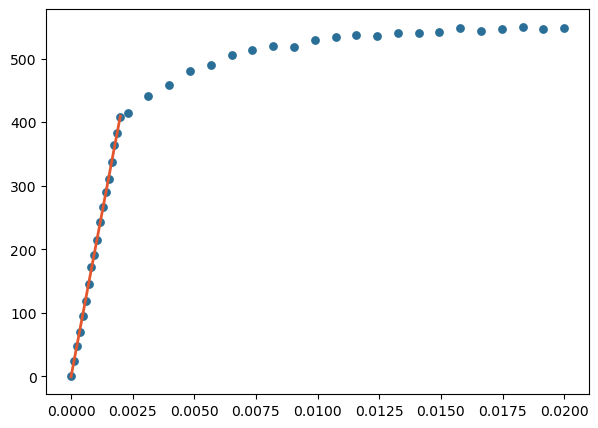

In [22]:
# ✏️ TODO: plot the original data, and the predicted regression line for the elastic region 
plt.figure(figsize=(7, 5))
plt.scatter(tensile["strain"], tensile["stress_mpa"], s=28, color="#2a6f97", label="data")
y_el_predict = model_el.predict(X_el)
plt.plot(X_el,y_el_predict, color="#e4572e", lw=2, label="linear fit")

### ✏️ Task A5 - Report Young's modulus & identify the material

The elastic slope **is** Young's modulus, in MPa. Convert it to GPa and compare with the reference values to guess the material.

In [23]:
# ✏️ TODO: convert the elastic slope to GPa (1 GPa = 1000 MPa)
E_gpa = model_el.coef_[0] / 1000
print(f"Young's modulus ~ {E_gpa:.0f} GPa")

# Reference Young's moduli (GPa):
#   aluminium ~70   |   titanium ~115   |   copper ~120   |   steel ~200
# Which one is your specimen?

Young's modulus ~ 205 GPa


### 🤔 Reflection A2

1. How close is your elastic-region slope to the full-range slope from Task A2? Why are they so different?
2. Suppose you used the full-range fit to *predict* the stress at a strain of 0.015. Would you trust it? What about predicting at a strain of 0.05 (well past your data)? Connect this to **interpolation vs extrapolation**.
3. One-liner: *a high R² alone does / does not* prove a linear model is appropriate. Explain using what you saw.

**Your answers:**

1. Elastic region slope: ~205 GPa, whereas the full slope ~ 22 GPa, a difference of almost a magnitude. They are different because when we consider all the data, as the curve flattens out after the elastic limit, the overal slope decreases. 
2. Looking at the first graph (or using the model to calculate) the stress at a strain of ~0.015 would be generally in good agreement with the experimental value. However, it's a special point that works as the linear regression line intersects the original data in that region. Nevertheless, it is still within the range of datapoints that the model was trained on (Interpolation), so the error is somewhat quantifiable (and expected).
   However, predicting the stress at a strain of 0.05 is not trustable as this is beyond the range of data that we have access to (Extrapolation). The linear regression line is likely to give a very high value, when in reality the material may have reached its breaking point by then.

3. This is evident in the second case where we selectively fitted to only the elastic region. The model has a high R2 value, however, it quickly reaches it's limit and the curve flattens out. If we want to model the full behaviour of a material we need a complex model that can fit to the entire region. Just because R2 value is high, that does not mean the model works under any condition.

---
## Part B - Thermal Expansion (Polynomial Regression)

Heat a metal and it expands. Over a *small* temperature range the strain grows roughly linearly with temperature, but over a **wide** range it curves upward - because the coefficient of thermal expansion (how fast it expands) itself increases with temperature. Engineering references routinely capture this with a **polynomial** in $T$.

Your dataset `thermal_expansion.csv`:
- `temperature_c` - temperature in °C
- `thermal_strain_ppm` - how much the specimen expanded, in parts-per-million (microstrain), measured relative to 20 °C

**Your mission:** find the polynomial degree that best captures the curve - without over-doing it.

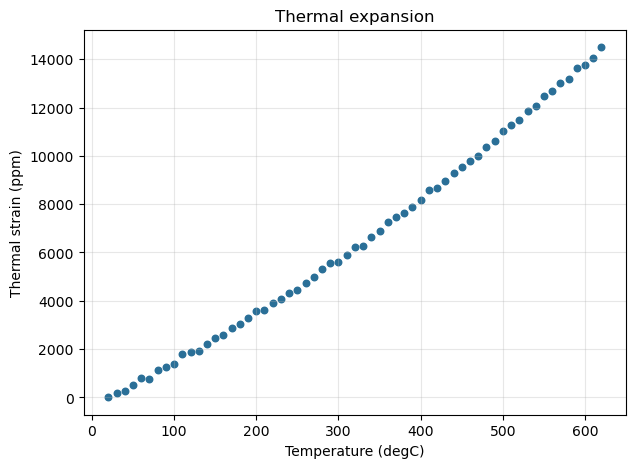

In [34]:
thermal = pd.read_csv("data/week03-HW_thermal_expansion.csv")

plt.figure(figsize=(7, 5))
plt.scatter(thermal["temperature_c"], thermal["thermal_strain_ppm"], s=22, color="#2a6f97")
plt.xlabel("Temperature (degC)")
plt.ylabel("Thermal strain (ppm)")
plt.title("Thermal expansion")
plt.grid(alpha=0.3)
plt.show()

### ✏️ Task B1 - Start with a straight line (degree 1)

We'll use NumPy's `np.polyfit(x, y, degree)`, which returns the polynomial coefficients, and `np.polyval(coeffs, x)` to evaluate the fit. Fit a degree-1 line, then plot its residuals.

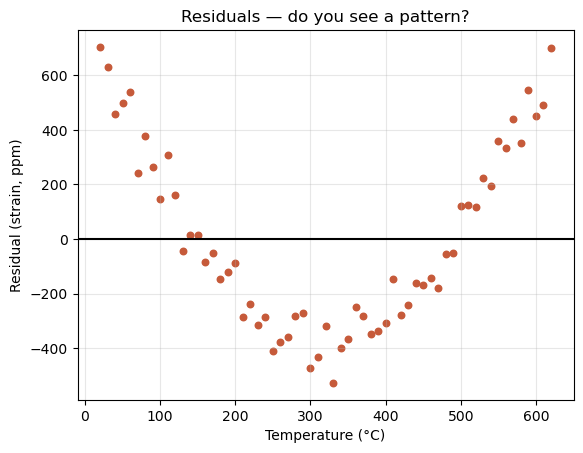

In [49]:
Tc         = thermal["temperature_c"].values.astype(float)
strain_ppm = thermal["thermal_strain_ppm"].values.astype(float)

coef1 = np.polyfit(Tc, strain_ppm, 1)   # degree-1 fit
fit1  = np.polyval(coef1, Tc)

# ✏️ TODO: plot the residuals (strain_ppm - fit1) against Tc, with a horizontal line at 0,
# just like the residual plot in Part A. Is it patternless, or is there a curve?

residuals1 = strain_ppm - fit1
plt.scatter(Tc,residuals1,s=22,color="#c65a3a")
plt.axhline(0,color='k')
plt.xlabel("Temperature (°C)")
plt.ylabel("Residual (strain, ppm)")
plt.title("Residuals — do you see a pattern?")
plt.grid(alpha=0.3)
plt.show()

### ✏️ Task B2 - Compare degrees 1, 2 and 3

Run the loop to compare R² across degrees. Then plot the degree-2 curve on top of the data.

degree 1:  R^2 = 0.9939
degree 2:  R^2 = 0.9997
degree 3:  R^2 = 0.9997


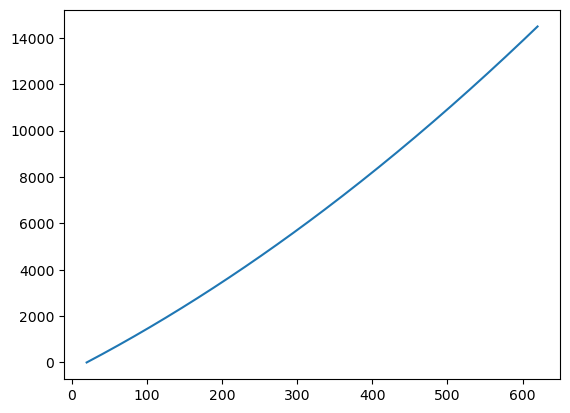

In [60]:
def r2_of(y, yhat):
    return 1 - np.sum((y - yhat)**2) / np.sum((y - np.mean(y))**2)

for deg in [1, 2, 3]:
    yhat = np.polyval(np.polyfit(Tc, strain_ppm, deg), Tc)
    print(f"degree {deg}:  R^2 = {r2_of(strain_ppm, yhat):.4f}")

# ✏️ TODO: plot the degree-2 fit as a smooth curve over the scatter.
# Hint: make a smooth grid  
T_grid = np.linspace(Tc.min(), Tc.max(), 200)
#       then plot np.polyval(np.polyfit(Tc, strain_ppm, 2), T_grid) vs T_grid.

plt.plot(T_grid, np.polyval(np.polyfit(Tc, strain_ppm, 2), T_grid))
plt.show()


### Task B3 - Higher degree ≠ better (run and observe)

This cell is complete - run it. It overlays a sensible degree-2 fit and a very high degree-12 fit, and **extrapolates 200 °C past the measured data** (dashed line marks the edge of the data). Watch what the high-degree curve does out there.

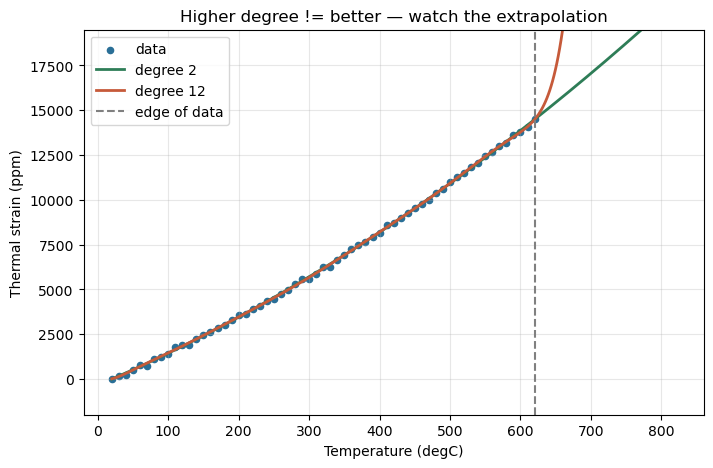

In [56]:
T_grid = np.linspace(Tc.min(), Tc.max() + 200, 400)   # note: extends PAST the data

plt.figure(figsize=(8, 5))
plt.scatter(Tc, strain_ppm, s=20, color="#2a6f97", label="data")
for deg, c in [(2, "#2e7d57"), (12, "#c65a3a")]:
    coef = np.polyfit(Tc, strain_ppm, deg)
    plt.plot(T_grid, np.polyval(coef, T_grid), color=c, lw=2, label=f"degree {deg}")
plt.axvline(Tc.max(), ls="--", color="grey", label="edge of data")
plt.ylim(strain_ppm.min() - 2000, strain_ppm.max() + 5000)
plt.xlabel("Temperature (degC)"); plt.ylabel("Thermal strain (ppm)")
plt.title("Higher degree != better — watch the extrapolation")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 🤔 Reflection B

1. Going from degree 1 to degree 2, how much did R² improve? From degree 2 to degree 3? Which degree would you choose, and why?
2. The degree-1 residuals had a clear shape, yet degree-1 still scored a *very high* R². What's the lesson about trusting R² on its own?
3. Look at the degree-12 curve beyond the dashed line. Why is extrapolating with a high-degree polynomial so risky? Link this back to Part A.
4. **Bonus (physical meaning):** the average slope of your fit is roughly the material's average coefficient of thermal expansion. Metals are typically 10–30 ×10⁻⁶ /°C. Does your fit land in that range?

**Your answers:**

1. From 0.9939 to 0.9997 - I would choose degree 2 - as there's almost no difference (difference could be in the 5th decimal) going from 2nd to 3rd order. Whereas going from 1st order to 2nd order there's a some improvement. 
2. Simply looking at the R2 may make you think that's a good fit, and that the thermal expansion is a linear function. But when looking at the residuals we can see that there's still some pattern remaining in the data which hasn't been fitted to! So we haven't captured the true relationship between the variables.
3. The 12 degree polynomial appears to fit the data almost perfectly! Too perfect in fact. So that the moment it moves beyond the known data, it shoots up rapidly. If we used a high degree polynomials for predictions - specially beyond our known region, our errors in prediction can be really high.
4. Check coef1 - for the first degree fit: the slope is ~24.1 which is in ppm, so the thermal expansion value for this material is 24 ×10⁻⁶ /°C, which is well within the acceptable range.
   Alternatively you can also consider the degree-2 fit - but the coefficients given in this case do not directly relate to the slope, so you will have to manually calculate the slope.

---
## This is a self-learning exercise ✅ Therefore you do not need to submit anything.
## A reference guide to the solutions will be posted later.

Nice work - you've now fit both a line and a curve to real materials behaviour, and you've learned to be a healthy skeptic about your own models. 🎉